In [15]:
# gọi hai thuật toán chạy trong notebook này
%run decision_tree.ipynb
%run randomForest.ipynb

In [17]:
# nhập thư viện
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [18]:
# lấy dữ liệu
data = pd.read_csv('drug200.csv')
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [19]:
# tạo tập X và y
X = data.drop(['Drug'], axis = 1) # frame
y = data['Drug'] # series

In [20]:
# xem giá trị xuất hiện của các cột định tính để biến đổi bước tiếp theo
# chúng ta có thể dùng set hoặc np.unique
print(set(X['Sex']))
print(set(X['BP']))
print(set(X['Cholesterol']))

print(set(y)) # xem tập y

{'F', 'M'}
{'NORMAL', 'HIGH', 'LOW'}
{'NORMAL', 'HIGH'}
{'DrugY', 'drugA', 'drugX', 'drugC', 'drugB'}


In [21]:
# biến đổi dữ liệu định tính sang định lượng: Sex, BP, Cholesterol và Drug
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1}) # 'M': 0, 'F': 1
X['BP'] = X['BP'].map({'HIGH': 2, 'NORMAL': 1, 'LOW': 0}) # 'HIGH': 2, 'NORMAL': 1, 'LOW': 0
X['Cholesterol'] = X['Cholesterol'].map({'HIGH': 1, 'NORMAL': 0}) # 'HIGH': 1, 'NORMAL': 0

y = y.map({'drugA': 0, 'drugB': 1, 'drugC': 2, 'drugX': 3, 'DrugY': 4}) # 'drugA': 0, 'drugB': 1, 'drugC': 2, 'drugX': 3, 'DrugY': 4

In [22]:
print(X)
print(y)

     Age  Sex  BP  Cholesterol  Na_to_K
0     23    1   2            1   25.355
1     47    0   0            1   13.093
2     47    0   0            1   10.114
3     28    1   1            1    7.798
4     61    1   0            1   18.043
..   ...  ...  ..          ...      ...
195   56    1   0            1   11.567
196   16    0   0            1   12.006
197   52    0   1            1    9.894
198   23    0   1            0   14.020
199   40    1   0            0   11.349

[200 rows x 5 columns]
0      4
1      2
2      2
3      3
4      4
      ..
195    2
196    2
197    3
198    3
199    3
Name: Drug, Length: 200, dtype: int64


In [23]:
# tạo dữ liệu train test với tỉ lệ tập test là 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 28)
print(X_train)
print(y_train)

     Age  Sex  BP  Cholesterol  Na_to_K
172   39    1   1            0   17.225
137   35    1   2            1   12.894
76    36    1   2            1   11.198
150   49    0   2            0    8.700
15    16    1   2            0   15.516
..   ...  ...  ..          ...      ...
3     28    1   1            1    7.798
32    49    0   0            0   11.014
22    47    0   0            0   30.568
5     22    1   1            1    8.607
1     47    0   0            1   13.093

[160 rows x 5 columns]
172    4
137    0
76     0
150    0
15     4
      ..
3      3
32     3
22     4
5      3
1      2
Name: Drug, Length: 160, dtype: int64


In [ ]:
# dùng model Decision Tree

In [30]:
decisionTree = DecisionTreeClass(min_samples_split = 2, max_depth = 10)

In [25]:
decisionTree.fit(X_train, y_train)

In [26]:
y_pred =  decisionTree.predict(X_test)
y_pred

array([3, 4, 3, 4, 0, 0, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 3,
       4, 3, 3, 3, 4, 0, 4, 4, 4, 4, 1, 4, 0, 4, 4, 4, 1, 4])

In [27]:
print(y_test.values)

[3 4 3 4 0 0 4 3 4 4 4 4 4 4 4 4 4 4 3 4 4 3 4 3 3 3 4 0 4 4 4 4 1 4 0 4 4
 4 1 4]


In [28]:
# độ chính xác
accuracy(y_test.values, y_pred)

1.0

In [29]:
# dùng model Random Forest

In [31]:
randomForest = RandomForest(n_trees = 3, n_features = 4)

In [ ]:
randomForest.fit(X_train, y_train)

In [ ]:
y_pred = randomForest.predict(X_test)
y_pred

In [ ]:
print(y_test.values)

In [ ]:
# độ chính xác
accuracy(y_test.values, y_pred)

In [2]:
# phát triển thêm:
# 1. Học thêm Decision Tree bằng thuật toán CART cho dự đoán cả Classification và Regression
# 2. Tìm hiểu về phương pháp cắt tỉa để giảm overfitting
# 3. Code lại baiTap sử dụng thư viện Scikit-learn
# 4. So sánh hai thuật toán của Decision Tree: ID3 (cái đang làm) và CART.

In [3]:
# Xem thêm ảnh dưới để biết thêm thuật toán nào nên dùng các kỹ thuật Scale
# Min-max scaler, Standard scaler, Robust scaler

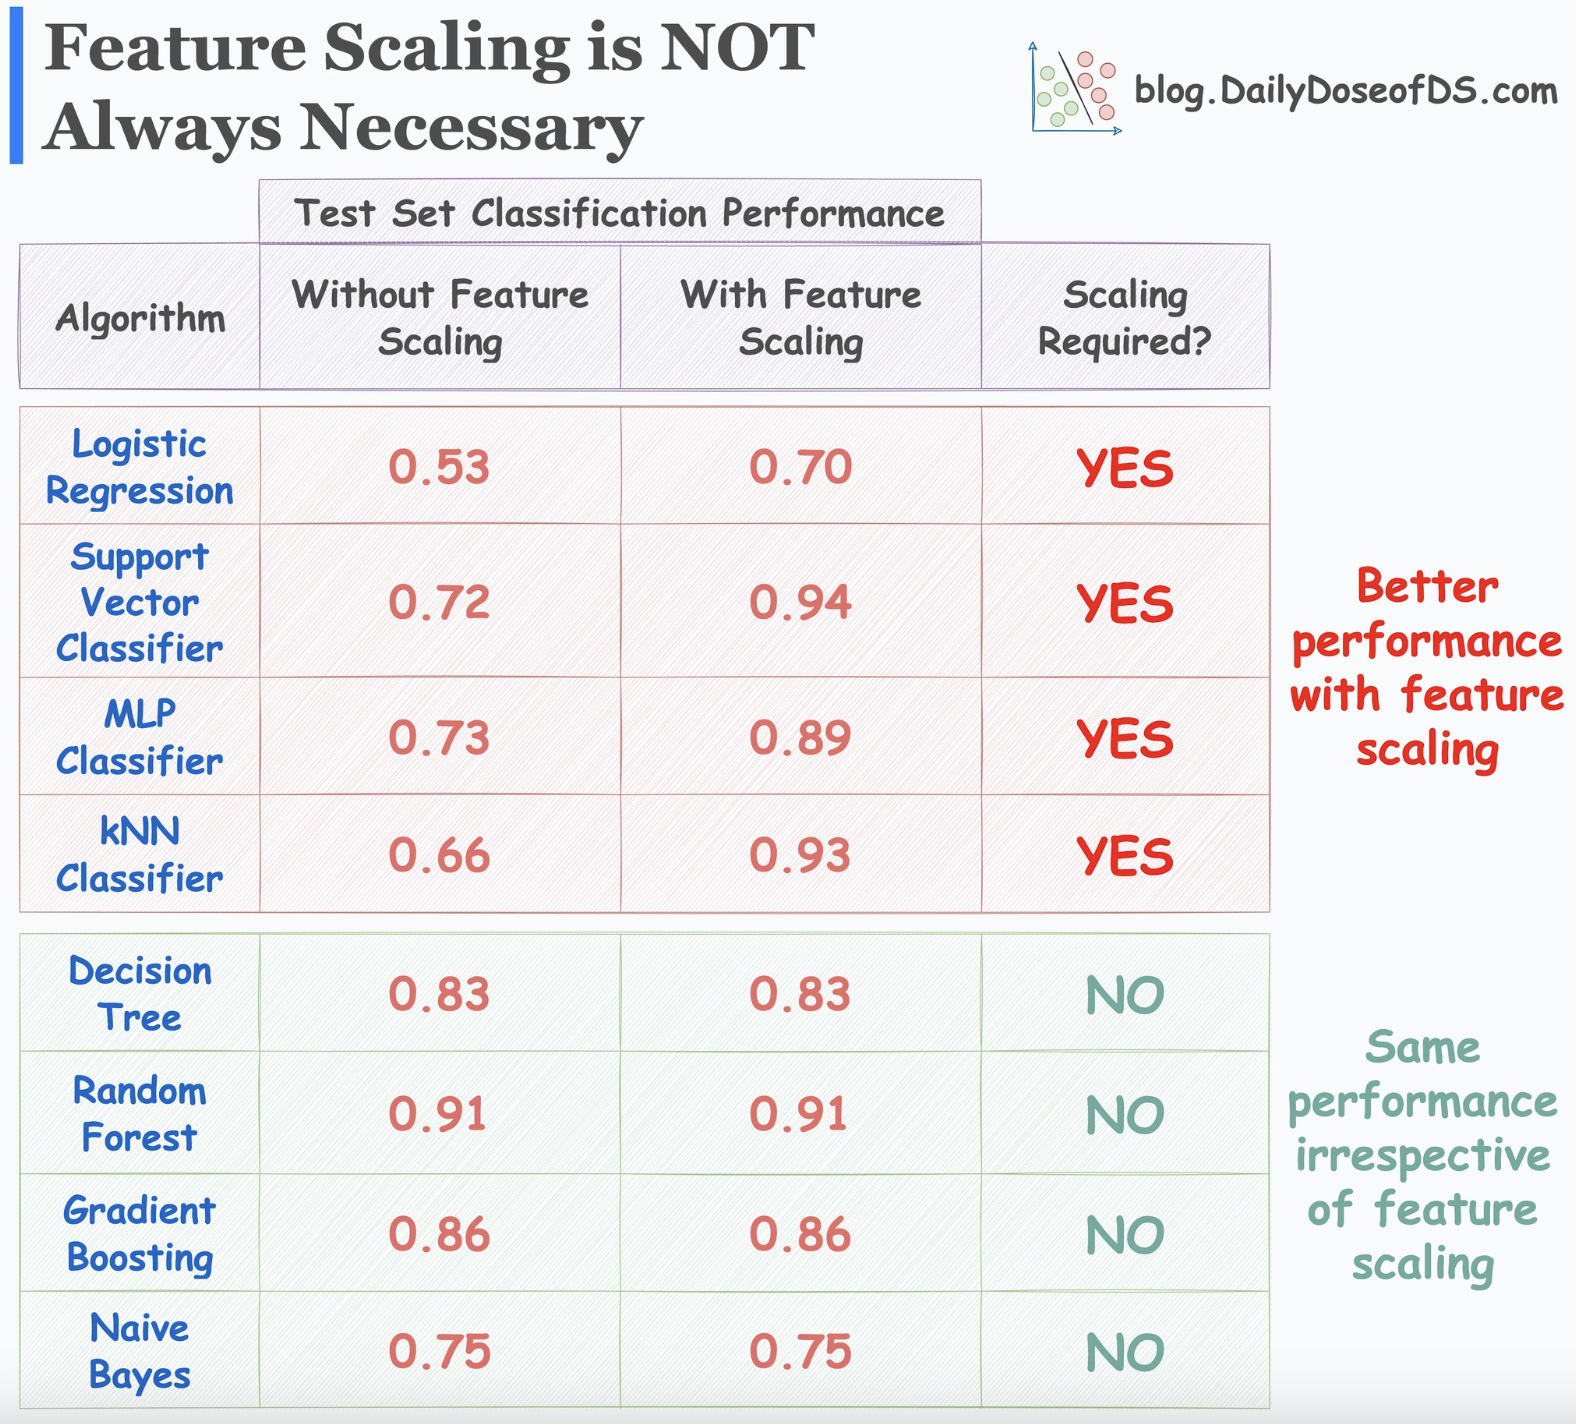